# A/B-тест: анализ ecommerce-эксперимента

## Бизнес-контекст
Интернет-магазин протестировал новый дизайн страницы. 
Цель — понять, стоит ли раскатывать изменение на всех пользователей.

## Вопрос исследования
Приводит ли новый дизайн к статистически значимому росту конверсии?

## Гипотезы
- H0: конверсия в группах не отличается
- H1: конверсия в новой группе выше

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('ab_data.csv')

print('Размер датасета:', df.shape)
print('\nТипы данных:')
print(df.dtypes)
print('\nПервые строки:')
df.head()

Размер датасета: (294480, 5)

Типы данных:
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

Первые строки:


,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [4]:
print('Пропуски:')
print(df.isnull().sum())

print('\nУникальные значения в группах:')
print(df['group'].value_counts())

print('\nУникальные значения в landing_page:')
print(df['landing_page'].value_counts())

Пропуски:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Уникальные значения в группах:
group
treatment    147278
control      147202
Name: count, dtype: int64

Уникальные значения в landing_page:
landing_page
new_page    147241
old_page    147239
Name: count, dtype: int64


In [5]:
# Несоответствия: treatment видит old_page или control видит new_page
mismatch = df[((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
              ((df['group'] == 'control') & (df['landing_page'] == 'new_page'))]

print('Количество несоответствий:', len(mismatch))
print('Это', round(len(mismatch) / len(df) * 100, 2), '% от всех данных')

Количество несоответствий: 3893
Это 1.32 % от всех данных


## Проблема в данных: несоответствие группы и страницы

Обнаружено 3893 строки (1.32%), где пользователь из группы `treatment` 
видел `old_page` или из `control` видел `new_page`.

Решение: удалить, а не исправлять — причина несоответствия неизвестна, 
любая правка была бы домыслом и исказила бы результаты теста.

In [6]:
# Удаляем строки с несоответствием группы и страницы
df_clean = df[((df['group'] == 'treatment') & (df['landing_page'] == 'new_page')) |
              ((df['group'] == 'control') & (df['landing_page'] == 'old_page'))]

print('Было строк:', len(df))
print('Стало строк:', len(df_clean))
print('Удалено:', len(df) - len(df_clean))

Было строк: 294480
Стало строк: 290587
Удалено: 3893


In [7]:
# Проверяем дубликаты по user_id
print('Всего пользователей:', df_clean['user_id'].nunique())
print('Всего строк:', len(df_clean))
print('Дубликаты:', len(df_clean) - df_clean['user_id'].nunique())

Всего пользователей: 290585
Всего строк: 290587
Дубликаты: 2


In [18]:
df_clean = df_clean.drop_duplicates(subset=['user_id'])
print('Строк после удаления дубликатов:', len(df_clean))

Строк после удаления дубликатов: 290585


## Итог чистки данных

Исходный датасет после удаления несоответствий: 290 587 строк.
Обнаружено 2 дубликата по `user_id` — один пользователь попал в обе группы,
что искажает результаты теста. Дубликаты удалены.

Финальный датасет: 290 585 строк.

In [20]:
converted_mean = df_clean.groupby("group")["converted"].mean()
print(converted_mean)

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64


(0.1, 0.13)

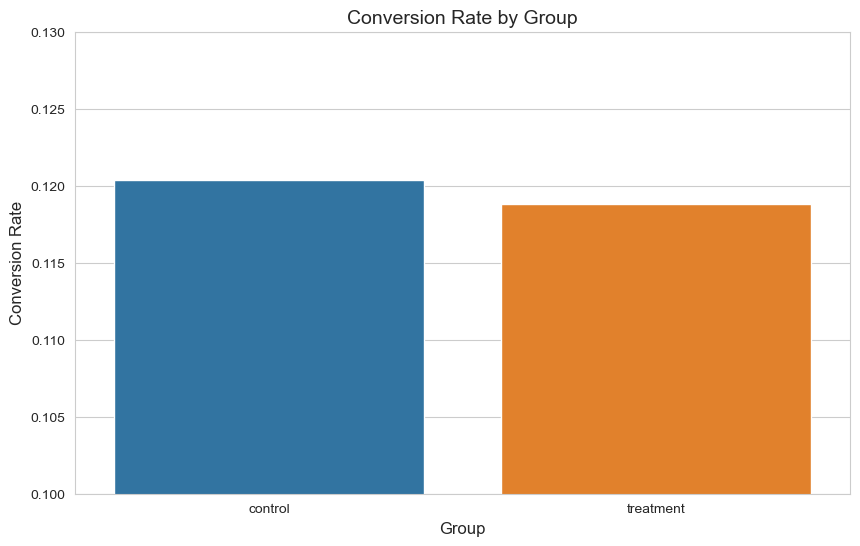

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

conversion_by_group = df_clean.groupby('group')['converted'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=conversion_by_group, x='group', y='converted')
plt.title('Conversion Rate by Group', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.ylim(0.10, 0.13)


## Конверсия по группам

- Контроль (старый дизайн): 12.04%
- Тест (новый дизайн): 11.88%

Визуально конверсия в контроле выше, но разница минимальная — 0.16%.
Необходимо проверить статистическую значимость этой разницы.

In [42]:
from statsmodels.stats.proportion import proportions_ztest



count = df_clean.groupby("group")["converted"].sum()
nobs = df_clean.groupby("group")["converted"].count()
z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-значение: {p_value:.4f}")

Z-статистика: 1.3116
p-значение: 0.1897


## Результаты z-test

- Z-статистика: 1.31 — разница между группами небольшая
- P-value: 0.19 — превышает порог 0.05

Вывод: разница в конверсии (12.04% vs 11.88%) статистически незначима.
Это значит, что с вероятностью 19% такая разница могла возникнуть случайно.

Рекомендация для PM: не раскатывать новый дизайн — 
он не показал значимого улучшения конверсии.



In [43]:

from statsmodels.stats.proportion import proportion_effectsize

p1 = converted_mean["control"]
p2 = converted_mean["treatment"]

h = proportion_effectsize(p1, p2)
print(f"Cohen's h = {h:.4f}")

Cohen's h = 0.0049


## Effect Size — Cohen's h

Cohen's h = 0.0049 — эффект практически нулевой.

Даже если бы разница оказалась статистически значимой,
на практике она настолько мала, что не имеет смысла для бизнеса.

## Итоговый вывод

Мы проверили, стоит ли раскатывать новый дизайн на всех пользователей.

**Что нашли в данных:**
- 3893 строки с нарушением рандомизации — удалены
- 2 дубликата по user_id — удалены

**Результаты анализа:**
- Конверсия: контроль 12.04% vs тест 11.88% — разница 0.16%
- Z-test: p-value = 0.19 > 0.05 — разница статистически случайна
- Cohen's h = 0.0049 — эффект практически нулевой
**Гипотезы:**
- H0 принята: конверсия в группах статистически не отличается
- H1 отвергнута: новый дизайн не доказал превосходства над старым

**Рекомендация для PM:**
Не раскатывать новый дизайн. Он не показал значимого улучшения конверсии.
Рекомендуется либо доработать дизайн и провести новый тест,
либо сосредоточиться на других гипотезах роста.